# Chapter 1 — Notebook 4: Detector resolution (reco vs truth)

**Goals**

- Compare reconstructed jets to the per-object truth jets (`truth_jet_*`).
- Match reco↔truth jets by ΔR and fit a Gaussian to the response with `iminuit`.

*Note: the open data has per-object truth (jets, leptons, MET) but no truth top/W mass.*

In [1]:
%matplotlib inline
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

from topmass import io, kinematics, selection, plotting, fitting, neutrino, pairing, weights, style
from topmass.constants import M_W, M_TOP

In [2]:
io.setup()                                  # select release 2025e-13tev-beta
samples = io.build_samples()                # skim '3J1LMET30', https
events = io.load_process('ttbar', samples, fraction=0.1)
print('Number of events:', len(events))

Fetching metadata for release: 2025e-13tev-beta...
Fetching datasets: 100%|██████████| 374/374 [00:00<00:00, 1274.83datasets/s]
✓ Successfully cached 374 datasets.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


Number of events: 636235


## Worked example: jet pT resolution via ΔR matching

In [3]:
reco = kinematics.jet_vectors(events)
truth = kinematics.truth_jet_vectors(events)

# Keep events with at least one reco and one truth jet
keep = (ak.num(reco) >= 1) & (ak.num(truth) >= 1)
reco, truth = reco[keep][:, 0], truth[keep]

# For each leading reco jet, find the closest truth jet
dr = reco.deltaR(truth)
closest = ak.argmin(dr, axis=1, keepdims=True)
matched_truth = ak.firsts(truth[closest])
matched_dr = ak.firsts(dr[closest])

good = matched_dr < 0.4
response = (reco.pt[good] / matched_truth.pt[good])
counts, edges = np.histogram(ak.to_numpy(response), bins=60, range=(0.5, 1.5))
result = fitting.fit_gaussian(counts.astype(float), edges)
print(result)
print('Jet pT resolution σ =', round(result.params['sigma'], 3))

FitResult(n: 1.017e+04 ± 13, mu: 1.003 ± 0.00014, sigma: 0.1112 ± 0.00014)
Jet pT resolution σ = 0.111


## ✏️ Your turn 4.1

▶️ Change the pT window and re-run.

This repeats the jet-pT resolution fit, but only for reco jets whose pT falls inside
`[PT_LO, PT_HI]`. Run it for low-pT jets, then change the window to high pT. Is the **relative**
resolution (σ) better at high or low pT?

> **Stretch (optional):** narrow the window further (e.g. `(40, 50)`) and see how the fit
> uncertainty grows as fewer jets enter.

In [4]:
PT_LO, PT_HI = 20, 60     # ✏️ then try 60, 1e9 for the high-pT region

good = (matched_dr < 0.4) & (reco.pt > PT_LO) & (reco.pt < PT_HI)
response = ak.to_numpy(reco.pt[good] / matched_truth.pt[good])
counts, edges = np.histogram(response, bins=60, range=(0.5, 1.5))
result = fitting.fit_gaussian(counts.astype(float), edges)
n = int(ak.sum(good))
print(f'pT in [{PT_LO}, {PT_HI}] GeV:  resolution σ = {result.params["sigma"]:.3f}   ({n} matched jets)')

pT in [20, 60] GeV:  resolution σ = 0.171   (72242 matched jets)


## ✏️ Your turn 4.2

▶️ Change the match cut and re-run.

This histograms the angular match quality `matched_dr` (ΔR between each leading reco jet and its
closest truth jet) and prints the fraction matched within `DR_MATCH`. What fraction of jets are
well-matched at the standard ΔR < 0.4?

> **Stretch (optional):** scan `DR_MATCH` over a few values and note how the matched fraction
> approaches 1.

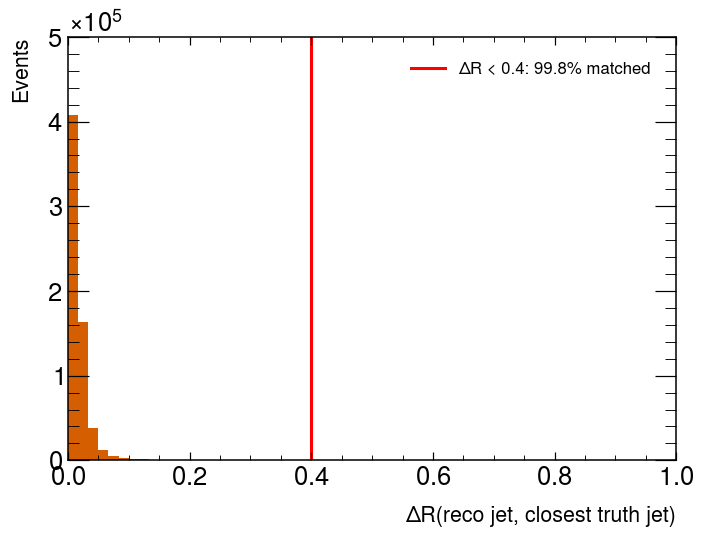

In [5]:
DR_MATCH = 0.4    # ✏️ try 0.1, 0.2, 0.4

frac = float(ak.mean(matched_dr < DR_MATCH))
plt.hist(ak.to_numpy(matched_dr), bins=60, range=(0, 1.0))
plt.axvline(DR_MATCH, color='red', label=f'ΔR < {DR_MATCH}: {frac:.1%} matched')
plt.xlabel('ΔR(reco jet, closest truth jet)'); plt.ylabel('Events'); plt.legend()